# Latent diffusion, guidance, and masked diffusion

Everything in Lecture 19 assembled on data small enough to run on a laptop:
an autoencoder that sets a reconstruction ceiling, a class-conditional
diffusion model trained in its latent space, classifier-free guidance, a
DDIM step-count sweep, and a masked diffusion model over tokens.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch import nn

torch.manual_seed(26521); np.random.seed(26521)
frame=pd.read_csv('SklearnDigits.csv'); X=frame.drop(columns='target').to_numpy(np.float32)/8-1; y=frame['target'].to_numpy()
images=torch.tensor(X); labels=torch.tensor(y).long()
images.shape, labels.shape

(torch.Size([1797, 64]), torch.Size([1797]))

## 1. The autoencoder sets a ceiling

Latent diffusion never sees a pixel. Whatever the decoder cannot draw is gone
before the denoiser starts, so the first thing to measure is `D(E(x))`.

reconstruction MSE 0.0208


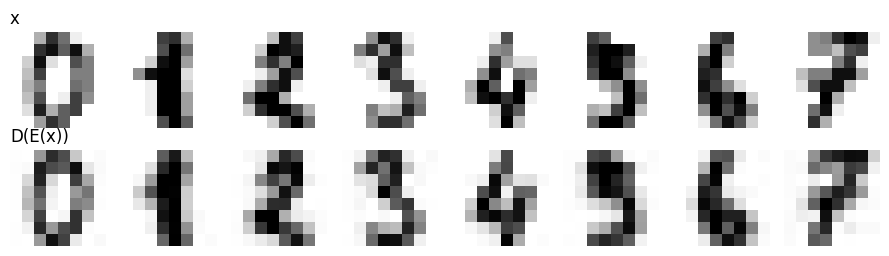

In [2]:
class AutoEncoder(nn.Module):
    def __init__(self, latent=12):
        super().__init__()
        self.enc=nn.Sequential(nn.Linear(64,128),nn.SiLU(),nn.Linear(128,latent))
        self.dec=nn.Sequential(nn.Linear(latent,128),nn.SiLU(),nn.Linear(128,64))
    def forward(self,x): return self.dec(self.enc(x))

ae=AutoEncoder(); opt=torch.optim.Adam(ae.parameters(),lr=2e-3)
for step in range(4000):
    batch=images[torch.randint(len(images),(256,))]
    loss=(ae(batch)-batch).square().mean()
    opt.zero_grad(); loss.backward(); opt.step()
print('reconstruction MSE', round(float(loss.detach()),4))

with torch.no_grad(): rec=ae(images[:8])
fig,axes=plt.subplots(2,8,figsize=(9,2.6))
for j in range(8):
    axes[0,j].imshow(images[j].reshape(8,8),cmap='gray_r',vmin=-1,vmax=1); axes[0,j].axis('off')
    axes[1,j].imshow(rec[j].reshape(8,8),cmap='gray_r',vmin=-1,vmax=1); axes[1,j].axis('off')
axes[0,0].set_title('x',loc='left'); axes[1,0].set_title('D(E(x))',loc='left'); plt.tight_layout()

## 2. A class-conditional diffusion model, trained in the latent space

The denoiser takes the noisy code, the level, and the digit label. The label is
dropped to a null token 15% of the time, which is what makes one network serve
both terms of classifier-free guidance.

In [3]:
with torch.no_grad(): codes=ae.enc(images)
scale=codes.std(); codes=codes/scale          # keep the latent near unit scale
NULL=10                                       # the null label

def alpha_bar(t): return torch.cos(torch.pi*t/2).square()

class Denoiser(nn.Module):
    def __init__(self, d=12, width=256):
        super().__init__()
        self.label=nn.Embedding(11,32); self.time=nn.Linear(1,32)
        self.net=nn.Sequential(nn.Linear(d+64,width),nn.SiLU(),
                               nn.Linear(width,width),nn.SiLU(),
                               nn.Linear(width,d))
    def forward(self,z,t,c):
        return self.net(torch.cat([z,self.time(t),self.label(c)],dim=1))

model=Denoiser(); opt=torch.optim.Adam(model.parameters(),lr=2e-3); history=[]
for step in range(8000):
    idx=torch.randint(len(codes),(256,)); z0=codes[idx]; c=labels[idx].clone()
    c[torch.rand(len(c))<0.15]=NULL                       # label dropout
    t=torch.rand(len(z0),1)*0.98+0.01; eps=torch.randn_like(z0)
    a=alpha_bar(t); zt=a.sqrt()*z0+(1-a).sqrt()*eps
    loss=(model(zt,t,c)-eps).square().mean()
    opt.zero_grad(); loss.backward(); opt.step(); history.append(float(loss))
print('final loss', round(float(np.mean(history[-200:])),4))

/var/folders/dw/twkl7xz54f59zmk2mt5tr7t40000gn/T/ipykernel_98681/2786622134.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  opt.zero_grad(); loss.backward(); opt.step(); history.append(float(loss))


final loss 0.2741


## 3. DDIM sampling with classifier-free guidance

One function does everything: the guided noise prediction, the implied clean
code, and the DDIM re-noising to the next level.

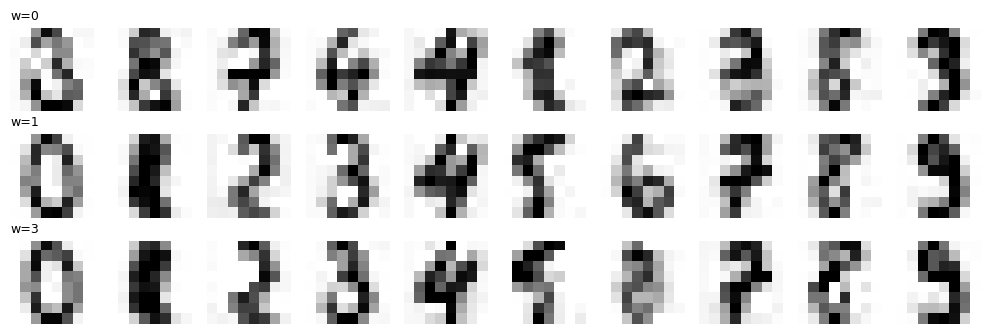

In [4]:
@torch.no_grad()
def sample(n, label, steps=20, w=3.0, seed=0):
    g=torch.Generator().manual_seed(seed)
    z=torch.randn(n,codes.shape[1],generator=g)
    c=torch.full((n,),label).long(); null=torch.full((n,),NULL).long()
    grid=torch.linspace(0.99,0.01,steps+1)
    for k in range(steps):
        t=torch.full((n,1),float(grid[k])); s=torch.full((n,1),float(grid[k+1]))
        e=model(z,t,null)+w*(model(z,t,c)-model(z,t,null))
        a_t,a_s=alpha_bar(t),alpha_bar(s)
        z0=((z-(1-a_t).sqrt()*e)/a_t.sqrt()).clamp(-4,4)
        z=(a_s.sqrt()*z0+(1-a_s).sqrt()*e).clamp(-6,6)   # keep the code in range
    return ae.dec(z*scale)

fig,axes=plt.subplots(3,10,figsize=(10,3.4))
for row,w in enumerate([0.0,1.0,3.0]):
    for digit in range(10):
        img=sample(1,digit,steps=20,w=w,seed=digit)[0]
        axes[row,digit].imshow(img.reshape(8,8),cmap='gray_r',vmin=-1,vmax=1); axes[row,digit].axis('off')
    axes[row,0].set_title(f'w={w:g}',loc='left',fontsize=9)
plt.tight_layout()

## 4. What the guidance scale actually trades

A small classifier trained on the real digits reports how often a sample is the
digit we asked for; the within-class pixel spread reports how varied the samples
are. Read the second column carefully: it falls as guidance removes diversity,
and then rises again once over-guidance produces artifacts rather than digits.
Neither column alone tells you where to set `w`.

In [5]:
probe=nn.Sequential(nn.Linear(64,128),nn.SiLU(),nn.Linear(128,10))
opt=torch.optim.Adam(probe.parameters(),lr=2e-3)
for step in range(3000):
    idx=torch.randint(len(images),(256,))
    loss=nn.functional.cross_entropy(probe(images[idx]),labels[idx])
    opt.zero_grad(); loss.backward(); opt.step()

rows=[]
for w in [0,1,2,3,5,8]:
    imgs=torch.cat([sample(40,d,steps=20,w=w,seed=100+d) for d in range(10)])
    want=torch.arange(10).repeat_interleave(40)
    with torch.no_grad(): acc=(probe(imgs).argmax(1)==want).float().mean()
    spread=imgs.reshape(10,40,64).std(dim=1).mean()
    rows.append((w,float(acc),float(spread)))
pd.DataFrame(rows,columns=['guidance w','matches the label','within-class spread'])

,guidance w,matches the label,within-class spread
0,0,0.0825,0.446030
1,1,0.9600,0.334080
2,2,0.9975,0.339482
3,3,0.9700,0.371638
4,5,0.7625,0.521057
5,8,0.6575,0.552805


## 5. How few steps can we get away with?

The model is fixed; only the number of network calls changes.

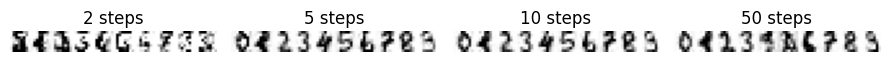

In [6]:
fig,axes=plt.subplots(1,4,figsize=(9,2.6))
for ax,steps in zip(axes,[2,5,10,50]):
    imgs=torch.cat([sample(1,d,steps=steps,w=3.0,seed=7) for d in range(10)])
    ax.imshow(np.hstack([im.reshape(8,8).numpy() for im in imgs]),cmap='gray_r',vmin=-1,vmax=1)
    ax.set_title(f'{steps} steps'); ax.axis('off')
plt.tight_layout()

## 6. Masked diffusion over tokens

Gaussian noise is meaningless for words, so the corruption becomes masking.
The corpus below is generated by a tiny grammar, the state at level `t` hides
each token independently with probability `t`, and the model predicts every
hidden token at once.

In [7]:
subjects=[['the','cat'],['a','dog'],['my','horse']]
verbs=[['sat'],['ran'],['slept']]
places=[['on','the','mat'],['in','the','park'],['by','the','door']]
rng=np.random.default_rng(26521)
corpus=[s+v+p for _ in range(3000)
        for s,v,p in [(subjects[rng.integers(3)],verbs[rng.integers(3)],places[rng.integers(3)])]]
vocab=sorted({w for seq in corpus for w in seq})+['[M]']
index={w:i for i,w in enumerate(vocab)}; MASK=index['[M]']; L=len(corpus[0]); V=len(vocab)
data=torch.tensor([[index[w] for w in seq] for seq in corpus])
print('vocabulary',V,'length',L); print(' '.join(corpus[0]))

vocabulary 16 length 6
my horse slept in the park


In [8]:
class MaskPredictor(nn.Module):
    def __init__(self, width=256):
        super().__init__()
        self.emb=nn.Embedding(V,32); self.pos=nn.Embedding(L,32)
        self.net=nn.Sequential(nn.Linear(L*32,width),nn.SiLU(),
                               nn.Linear(width,width),nn.SiLU(),
                               nn.Linear(width,L*V))
    def forward(self,x):
        h=self.emb(x)+self.pos(torch.arange(L))
        return self.net(h.flatten(1)).reshape(-1,L,V)

mask_model=MaskPredictor(); opt=torch.optim.Adam(mask_model.parameters(),lr=2e-3)
for step in range(4000):
    x0=data[torch.randint(len(data),(256,))]
    t=torch.rand(len(x0),1)
    hidden=torch.rand(x0.shape)<t
    xt=torch.where(hidden,torch.full_like(x0,MASK),x0)
    logits=mask_model(xt)
    per=nn.functional.cross_entropy(logits.reshape(-1,V),x0.reshape(-1),reduction='none').reshape(x0.shape)
    loss=((per*hidden).sum(1)/t.squeeze(1)).mean()/L      # the 1/t weighting
    opt.zero_grad(); loss.backward(); opt.step()
print('final loss', round(float(loss),4))

final loss 0.5263


## 7. Sampling: unmask the confident positions, re-mask the rest

In [9]:
@torch.no_grad()
def generate(rounds=4, seed=0):
    g=torch.Generator().manual_seed(seed)
    x=torch.full((1,L),MASK); trace=[x.clone()]
    for r in range(rounds):
        probs=mask_model(x).softmax(-1)
        draw=torch.multinomial(probs[0],1,generator=g).squeeze(1)
        conf=probs[0].gather(1,draw[:,None]).squeeze(1)
        still=(x[0]==MASK)
        keep=max(1,int(still.sum().item()*(1-(rounds-r-1)/rounds)))
        order=torch.argsort(torch.where(still,conf,torch.full_like(conf,-1)),descending=True)
        chosen=order[:keep]
        x[0,chosen]=draw[chosen]
        trace.append(x.clone())
    return trace

for seed in range(3):
    for step,state in enumerate(generate(rounds=4,seed=seed)):
        print(f'round {step}:', ' '.join(vocab[i] for i in state[0]))
    print()

round 0: [M] [M] [M] [M] [M] [M]
round 1: [M] [M] [M] [M] the [M]
round 2: [M] dog [M] in the [M]
round 3: a dog [M] in the park
round 4: a dog slept in the park

round 0: [M] [M] [M] [M] [M] [M]
round 1: [M] [M] [M] [M] the [M]
round 2: [M] [M] [M] by the park
round 3: a horse [M] by the park
round 4: a horse ran by the park

round 0: [M] [M] [M] [M] [M] [M]
round 1: [M] [M] [M] [M] the [M]
round 2: [M] [M] [M] in the park
round 3: the dog [M] in the park
round 4: the dog slept in the park

